<a href="https://colab.research.google.com/github/nikamade/Data201/blob/main/Week4AssignmentLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment – Week 4**

## **Logistic Regression: R → Python Bridge**

**Course**: Data Science

**Submission**: Jupyter Notebook (.ipynb)

**Dataset**: housing.csv

--------------------------------------
# **Learning Objectives**
By the end of this assignment, you should be able to:

* Fit and interpret logistic regression models

* Translate workflows from **R (glm / tidymodels) to Python**

* Interpret **odds ratios**

* Evaluate classification models using **Accuracy and ROC–AUC**
* Reflect on the difference between **statistical inference vs prediction**
--------------------------------------
## **Dataset Description**

The dataset contains **600 housing listings.**

**Variable**	       **Description**
listing_id	         Unique identifier

price	               Sale price of the house

size	               House size (square footage)

bedrooms	           Number of bedrooms

neighborhood	       Location category

type	               Housing type (SingleFamily, Townhouse, MultiFamily)
--------------------------------------
# **Step 0 – Create a Binary Outcome**

For classification, convert price into a binary variable.

high_price = price > median(price)
This creates two groups:

* 1 → expensive homes
* 0 → less expensive homes

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/nikamade/Data201/refs/heads/main/Dataset/housing.csv")
df["high_price"] = np.where(df["price"] > np.median(df["price"]), 1,0)

# **Part A – Logistic Regression for Inference**

**In Python**

Fit the equivalent model using **statsmodels**.

Example:

import statsmodels.formula.api as smf

model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

print(model.summary())

In [2]:
import statsmodels.formula.api as smf

model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.01177
Time:                        18:53:54   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

**Report**
Create a table including:

* coefficients
* odds ratios
* p-values
Odds ratios:


odds_ratio = exp(coefficient)

In [3]:
# coefficient

coefficient = model.params

# p-values
pvalues = model.pvalues

# Odds ratios
odds_ratios = np.exp(coefficient)

# Combine into a DataFrame
report_table = pd.DataFrame({
    "Coefficient": coefficient,
    "Odds Ratio": odds_ratios,
    "p-value": pvalues
})

# Round for readability
report_table = report_table.round(3)

print(report_table)


                               Coefficient  Odds Ratio  p-value
Intercept                            0.380       1.462    0.190
C(neighborhood)[T.Midtown]          -0.307       0.736    0.278
C(neighborhood)[T.Suburb]            0.107       1.113    0.675
C(neighborhood)[T.Uptown]            0.047       1.048    0.865
C(neighborhood)[T.Waterfront]        0.413       1.511    0.243
size                                -0.001       0.999    0.037
bedrooms                             0.232       1.261    0.082


### **Short Analysis**
Answer:

Which predictors appear statistically significant?**Answer:** size appears to be statistically  significant because her pvalues is 0.037 and is less than 0.05


Which neighborhood has higher odds of expensive homes? **Answer**: neighborhood T.Waterfront with 1.511  

# **Part B – Interpretation (Plain Language)**
Choose one variable and explain its odds ratio. the ratio of size is 0.999


For every additional foot square , the odds of a house being expensive decrease by 0.1%.which means that big house are likely to be less expensive.

Your explanation should be understandable to someone without statistics training.

# **Part C – Prediction Workflow**
**(tidymodels → scikit-learn)**

** 1. Train/Test Split
Split the data:**

80% training
20% testing
Example:


2. Fit Logistic Regression Use:

sklearn.linear_model.LogisticRegression Encode categorical variables such as:

neighborhood type

3. Evaluate the Model ( check slides for more info about this) Report: Accuracy ROC–AUC Useful functions: sklearn.metrics.accuracy_score sklearn.metrics.roc_auc_score Optional: plot an ROC curve.



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
df_encoded = pd.get_dummies(df, columns=["neighborhood","type"], drop_first=True)
df_encoded = df_encoded.dropna()
X = df_encoded.drop(["high_price","listing_id","price"], axis=1)
y = df_encoded["high_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", auc)



Accuracy: 0.4666666666666667
ROC-AUC: 0.43936092955700795


In [5]:
df.isna().sum()

,0
listing_id,0
price,0
size,53
bedrooms,24
neighborhood,0
type,0
high_price,0


# **Part D – Model Understanding**

 Accuracy vs AUC // **Answer**:Accuracy measures the proportion of correct predictions while AUC evaluates how well the model distinguishes between expensive and less expensive homes across different thresholds.

 Why might ROC–AUC sometimes be preferred over accuracy? Explain in 2–3 sentences.  // **Answer**: because the fact that it can separate the result between the 2 study(the yes or no) avoid mistake.

  Inference vs Prediction Which modeling approach would you choose for:
   Policy analysis :  ** ANSWER** statsmodels: the gaol is to interpret the relationships between variables.
  
   Prediction tasks Explain why **ANSWER**  scikit-learn :models focused on predictive performance are preferred because the goal is to make accurate predictions



## **Part E – Explore the Dataset Before modeling, briefly explore the data**.

 Create at least three plots such as:

 Histogram of price

 Scatter plot: size vs price

 Boxplot: price by neighborhood

 Bar chart: housing type

  Discuss one interesting pattern you observe



*   List item
*   List item






 ** Histogram of price**

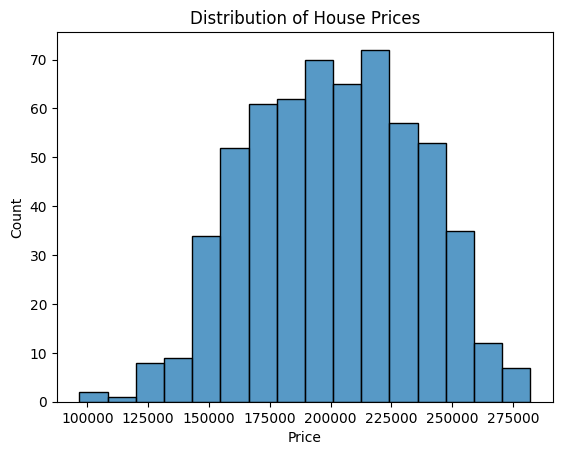

In [6]:
sns.histplot(df["price"])
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

 **Scatter plot: size vs price**

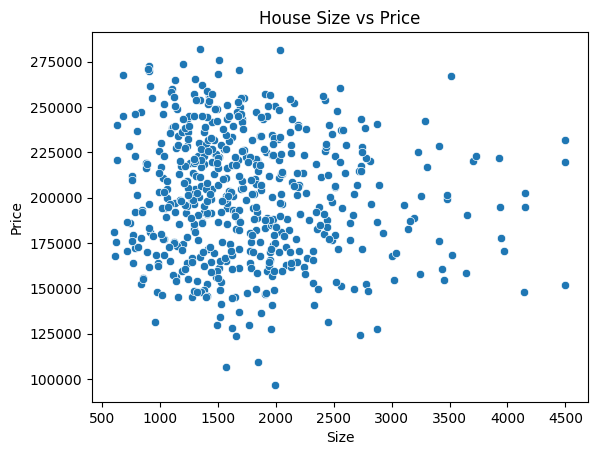

In [7]:
sns.scatterplot(x="size", y="price", data=df)
plt.title("House Size vs Price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

 **size vs price Boxplot: price by neighborhood**

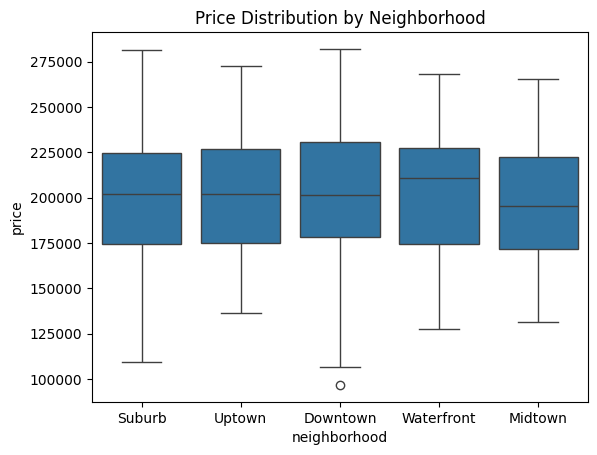

In [8]:
sns.boxplot(x="neighborhood", y="price", data=df)
plt.title("Price Distribution by Neighborhood")
plt.show()

In my scatter plot, we can observe that some larger houses are priced lower than smaller ones, even though we would generally expect the opposite trend.